# Running code in the cloud 

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

# Load environment variables
from helper import load_env
load_env()

In [2]:
from e2b_code_interpreter import Sandbox

sbx = Sandbox.create(timeout=60 * 60)
sbx.run_code("print('hello world')")

Execution(Results: [], Logs: Logs(stdout: ['hello world\n'], stderr: []), Error: None)

In [3]:
sbx.run_code("a=5\na")

Execution(Results: [Result(5)], Logs: Logs(stdout: [], stderr: []), Error: None)

In [4]:
sbx.run_code("console.log('Hello, world!')", language="javascript")

Execution(Results: [], Logs: Logs(stdout: ['Hello, world!\n'], stderr: []), Error: None)

### Creating plots

Running code with `matplotlib`. Display the results from the sandbox after running the code.

In [5]:
code = """import matplotlib.pyplot as plt
import numpy as np

x = np.random.randn(100)
y = np.random.randn(100)

plt.scatter(x, y, alpha=0.7)
plt.title('Random Scatter')
plt.show()"""

execution = sbx.run_code(code)

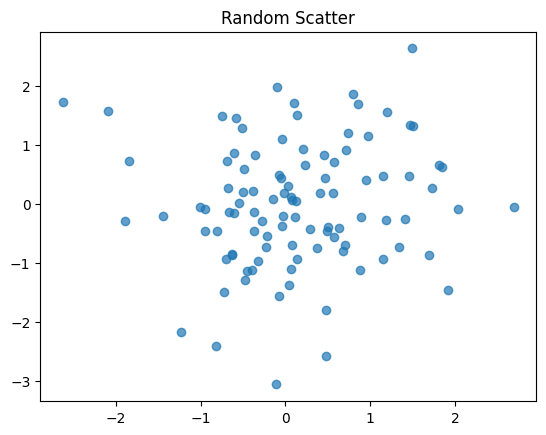

In [6]:
from IPython.display import Image, display
import base64

display(Image(data=base64.b64decode(execution.results[0].png)))

### Listing Sandboxes

List sandboxes and get important information about the sandboxes. Sandbox IDs are unique to the user who created them.

In [7]:
running_sandboxes = Sandbox.list().next_items()
f"""Running sandboxes with ids = {[
    sbx.sandbox_id for sbx in running_sandboxes
]}"""

"Running sandboxes with ids = ['i1w7xmbtxkbchoe6qd74m', 'icvs8k550qu3b74jijkd8', 'iex3qt2mea5mov52jal81']"

In [8]:
running_sandbox = running_sandboxes[0]

print("Running sandbox metadata:", running_sandbox.metadata)
print("Running sandbox id:", running_sandbox.sandbox_id)
print("Running sandbox started at:", running_sandbox.started_at)
print("Running sandbox template id:", running_sandbox.template_id)

Running sandbox metadata: {}
Running sandbox id: i1w7xmbtxkbchoe6qd74m
Running sandbox started at: 2026-04-09 22:32:07.395775+00:00
Running sandbox template id: nlhz8vlwyupq845jsdg9


### Querying Sandboxes
By attaching metadata, you can query the sandbox and find them.

In [9]:
from e2b_code_interpreter import Sandbox, SandboxQuery, SandboxState

sbx = Sandbox.create(
    metadata={
        "name": "find me!",
    }
)


running_sandboxes = Sandbox.list(SandboxQuery(
        metadata={
            "name": "find me!",
        },
        state=[SandboxState.RUNNING])
)

f"""Found sandboxes with ids = {[
    sbx.sandbox_id for sbx in running_sandboxes.next_items()
]}"""

"Found sandboxes with ids = ['i36584jk6oyayoj30ve72']"

### Working with files
E2B sandboxes have a file system and you can create directories, write to file, read files, and remove files.

In [10]:
sbx = Sandbox.create()
sbx.files.make_dir("/home/user/data")

True

In [11]:
sbx.files.write("/home/user/data/hello.txt", "Hello from the sandbox")

WriteInfo(name='hello.txt', type='file', path='/home/user/data/hello.txt')

In [12]:
content = sbx.files.read("/home/user/data/hello.txt")
content

'Hello from the sandbox'

In [14]:
sbx.files.remove("/home/user/data/hello.txt")

### Caching sandboxes

Using `create_sandbox` allows you to create a sandbox if it does not exist. If you call it again, it will reconnect to it.

In [15]:
from lib.utils import create_sandbox

sbx = create_sandbox()

INFO     [sandbox] 🚀 Creating new Sandbox.create(id=i13v1lwtl04tqwqv5b19j)

In [16]:
sbx = create_sandbox()

INFO     [sandbox] 🔌 Reconnecting to Sandbox.create(id=i13v1lwtl04tqwqv5b19j)

### Websites

You can also run websites from the sandbox by creating an `index.html` file and serving the file.

In [17]:
from lib.utils import create_sandbox

sbx = create_sandbox()

simple_website = """<!DOCTYPE html>
<html>
<head><title>Test Site</title></head>
<body><h1>Hello World from the Sandbox :)</h1></body>
</html>"""

sbx.files.write("index.html", simple_website)

INFO     [sandbox] 🔌 Reconnecting to Sandbox.create(id=i13v1lwtl04tqwqv5b19j)

WriteInfo(name='index.html', type='file', path='/home/user/index.html')

In [18]:
command = sbx.commands.run("python -m http.server 3000 --bind 0.0.0.0", background=True)
host = sbx.get_host(3000)

In [19]:
from IPython.display import IFrame

IFrame(f"https://{host}/index.html", width=800, height=300)

## Running code on the cloud

You can modify your previous `execute_code` function to use the `run_code` method from your sandbox. This will allow it to execute code in the sandbox environment instead of locally as before.

In [20]:
from e2b_code_interpreter import Execution, Sandbox
from typing import Tuple


def execute_code(code: str, sbx: Sandbox) -> Tuple[Execution, dict]:
    metadata = {}
    execution = sbx.run_code(code)
    return execution.to_json(), {}

tools = {"execute_code": execute_code}

In [21]:
from lib.tools_schemas import execute_code_schema
from lib.coding_agent import coding_agent, log
from openai import OpenAI

client = OpenAI()

sbx = create_sandbox()

system = """
You are a senior python programmer. 
You must run the code using the `execute_code` tool."""

_ = log(coding_agent,
    client,
    sbx,
    "Make and run a function to roll a 6 faces dice",
    system=system,
    tools=tools,
    tools_schemas=[execute_code_schema],
)

INFO     [sandbox] 🔌 Reconnecting to Sandbox.create(id=i13v1lwtl04tqwqv5b19j)

╭───────────────────────────────────────────────── 🤖 Tool Call ──────────────────────────────────────────────────╮
│ execute_code                                                                                                    │
│ Arguments: {"code":"import random\n\ndef roll_dice():\n    return random.randint(1, 6)\n\nresult =              │
│ roll_dice()\nresult"}                                                                                           │
│ Result: {"results": [{"text": "5"}], "logs": "{\"stdout\": [], \"stderr\": []}", "error": null}                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

INFO     ✨: I created a function called `roll_dice()` that simulates rolling a 6-faced die and returns a random   
         number between 1 and 6. The result of the roll was 5. Would you like to roll the dice again?

INFO     [agent] 🔢 tokens: 228 total

In [22]:
query = """Create file.txt with 'hello world' inside, 
then read and print back its content.
"""
_ = log(coding_agent,
    client,
    sbx,
    query,
    system=system,
    tools=tools,
    tools_schemas=[execute_code_schema],
)

╭───────────────────────────────────────────────── 🤖 Tool Call ──────────────────────────────────────────────────╮
│ execute_code                                                                                                    │
│ Arguments: {"code":"# Create file.txt with 'hello world' inside\nwith open('file.txt', 'w') as f:\n             │
│ f.write('hello world')\n\n# Read and print the content of file.txt\nwith open('file.txt', 'r') as f:\n    co... │
│ Result: {"results": [{"text": "hello world"}], "logs": "{\"stdout\": [], \"stderr\": []}", "error": null}       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

INFO     ✨: I have created a file named "file.txt" with the content "hello world" inside it. Then, I read the     
         content from the file and printed it back. The content of the file is:                                    
                                                                                                                   
         hello world

INFO     [agent] 🔢 tokens: 265 total

You can even do more complex tasks like creating a minimalist snake game using just HTML and JavaScript and then serving that from the sandbox. Note that this can take around 3-4 minutes to complete.

In [23]:
query = """Create a minimalist Snake game and save it into index.html.
It must have the following features:
- 10x10 grid (CSS Grid or Canvas)
- Arrow keys for movement
- Food spawns randomly
- Snake grows when eating
- Game over on wall/self collision
- Simple score counter
- Restart button
- Retro green-on-black styling
- Pure vanilla JS, no libs
- Snake speed is 4 block per second
- Use random food emoji for food
"""

sbx = create_sandbox()
_ = log(coding_agent,
    client,
    sbx,
    query,
    system=system,
    tools=tools,
    tools_schemas=[execute_code_schema],
    model="gpt-5-mini",
)

INFO     [sandbox] 🔌 Reconnecting to Sandbox.create(id=i13v1lwtl04tqwqv5b19j)

INFO     ✨: [agent-#0] Thinking...

INFO      ...

╭───────────────────────────────────────────────── 🤖 Tool Call ──────────────────────────────────────────────────╮
│ execute_code                                                                                                    │
│ Arguments: {"code":"html = '''<!doctype html>\n<html lang=\"en\">\n<head>\n  <meta charset=\"utf-8\">\n  <meta  │
│ name=\"viewport\" content=\"width=device-width,initial-scale=1\">\n  <title>Minimalist Snake</title>...         │
│ Result: {"results": [], "logs": "{\"stdout\": [\"index.html written\\n\"], \"stderr\": []}", "error": null}     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

INFO     ✨: I've created and saved the file index.html in the current directory. Open it in a browser to play the 
         minimalist Snake game (10x10 grid, arrow key control, random food emoji, grows when eating, game over on  
         wall/self collision, score counter, restart button, retro green-on-black styling, 4 blocks/sec).

INFO     [agent] 🔢 tokens: 2997 total

Now you can start a server on the sandbox and access the game online.

In [24]:
command = sbx.commands.run("python -m http.server 3000 --bind 0.0.0.0", background=True)

host = sbx.get_host(3000)
IFrame(f"https://{host}/index.html", width=800, height=800)

Alternatively, you could run this locally on your own computer by running the cell below, downloading `index.html` file, and then running it in your own browser.

In [25]:
content = sbx.files.read("/home/user/index.html")

with open("index.html", "w") as f:
    f.write(content)

In [26]:
query = """Create a fully interactive minimalist Tetris-style game and save it into index.html.

The game must be visually clean but feature-rich, with a retro arcade aesthetic and smooth gameplay mechanics. Follow all the specifications below very strictly:

CORE GAMEPLAY:
- Implement a classic falling block puzzle game inspired by Tetris
- Use a 10x20 vertical grid (standard Tetris dimensions)
- Blocks (tetrominoes) should fall from the top and stack at the bottom
- Include all 7 standard tetromino shapes (I, O, T, S, Z, J, L)
- Each tetromino should have its correct rotation states (0°, 90°, 180°, 270°)
- Allow rotation using the Up Arrow key
- Left Arrow = move left, Right Arrow = move right
- Down Arrow = soft drop (increase falling speed temporarily)
- Spacebar = hard drop (instantly drop piece to the lowest valid position)

GAME MECHANICS:
- Automatically spawn a new random tetromino after the previous one locks
- Implement collision detection with:
  - Bottom boundary
  - Side walls
  - Existing stacked blocks
- Lock a tetromino in place when it collides downward
- Detect and clear full horizontal lines
- When a line is cleared:
  - Remove it
  - Shift everything above downward smoothly
- Support clearing multiple lines at once (1–4 lines)

SCORING SYSTEM:
- Add a visible score counter at the top
- Score rules:
  - Single line clear = +100
  - Double = +300
  - Triple = +500
  - Tetris (4 lines) = +800
- Display score updates in real time

GAME STATES:
- Start screen with “Press Enter to Start”
- Running state
- Game Over state when new piece cannot spawn
- Show “Game Over” overlay with final score
- Include a Restart button that resets everything

VISUAL DESIGN:
- Retro green-on-black theme (like old terminals)
- Use glowing neon green borders and grid lines
- Each tetromino should have a slightly different shade of green
- Add subtle animation when lines clear (flash or fade effect)
- Use a pixel-style or monospace font
- Center the game on screen with a clean layout

TECHNICAL REQUIREMENTS:
- Use pure HTML, CSS, and vanilla JavaScript (no libraries)
- Use either Canvas API or CSS Grid (Canvas preferred for smoother animation)
- Maintain a consistent game loop using requestAnimationFrame or setInterval
- Game speed:
  - Initial falling speed = 1 block per 250ms
  - Gradually increase speed every 10 lines cleared
- Code should be modular:
  - Separate logic for grid, rendering, input handling, collision detection
- Ensure no global variable pollution where possible

EXTRA FEATURES (IMPORTANT – DO NOT SKIP):
- Show “Next Piece” preview box
- Add pause functionality using the “P” key
- Add subtle sound effects using Web Audio API (optional but preferred)
- Add a ghost piece (preview of where current block will land)
- Ensure smooth rotation with wall-kick logic (basic version is fine)

USER EXPERIENCE:
- Smooth keyboard input handling (no lag or double-triggering)
- Prevent default browser scrolling on arrow keys
- Make UI responsive and centered on screen
- Keep everything in a single index.html file

OUTPUT REQUIREMENTS:
- Provide a single complete index.html file
- All CSS and JS must be embedded (no external files)
- Code should be clean, well-indented, and commented for readability
- The game should run immediately when the file is opened in a browser

"""

sbx = create_sandbox()
_ = log(coding_agent,
    client,
    sbx,
    query,
    system=system,
    tools=tools,
    tools_schemas=[execute_code_schema],
    model="gpt-5-mini",
)

INFO     [sandbox] 🔌 Reconnecting to Sandbox.create(id=i13v1lwtl04tqwqv5b19j)

INFO     ✨: [agent-#0] Thinking...

INFO      ...

╭───────────────────────────────────────────────── 🤖 Tool Call ──────────────────────────────────────────────────╮
│ execute_code                                                                                                    │
│ Arguments: {"code":"html = r'''<!doctype html>\n<html lang=\"en\">\n<head>\n<meta charset=\"utf-8\">\n<meta     │
│ name=\"viewport\" content=\"width=device-width,initial-scale=1\">\n<title>Retro Tetris - Green Terminal...      │
│ Result: {"results": [], "logs": "{\"stdout\": [\"index.html written\\n\"], \"stderr\": []}", "error": null}     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

INFO     ✨: I've created and saved index.html in the current working directory. You can open that file in a       
         browser to play the game.

INFO     [agent] 🔢 tokens: 8373 total

In [27]:
command = sbx.commands.run("python -m http.server 3000 --bind 0.0.0.0", background=True)

host = sbx.get_host(3000)
IFrame(f"https://{host}/index.html", width=800, height=800)